# Personalized Drug Response Predictor (Pharmacogenomics AI)

## Objective
This project aims to predict drug response (Effective, Toxic, Ineffective) based on genetic features such as gene expression levels and SNP variations. The goal is to demonstrate how pharmacogenomics can support personalized medicine using machine learning.

## Background
Pharmacogenomics studies how genetic variation influences drug response. Differences in genes such as those involved in drug metabolism (e.g., CYP enzymes) can affect drug efficacy and toxicity.

## Workflow
1. Synthetic dataset creation (simulating gene expression + SNP data)
2. Data preprocessing and encoding
3. Exploratory Data Analysis (EDA)
4. Feature engineering
5. Model training (Random Forest, Gradient Boosting)
6. Model evaluation
7. Feature importance and interpretation
8. Patient-level prediction

## Technologies Used
- Python
- Pandas, NumPy
- Seaborn, Matplotlib
- Scikit-learn

## Expected Outcome
- Predict drug response based on genetic features
- Identify key genetic factors influencing drug behavior
- Demonstrate real-world application of AI in precision medicine

Dataset Head:
     Gene_A    Gene_B    Gene_C    Gene_D  SNP_1  SNP_2  Drug_Response
0  0.599343  1.277853  1.149839  1.511344      1      2              0
1  0.472347  1.572825  1.031158  0.979526      2      2              0
2  0.629538  0.580430  0.814908  0.872720      1      0              1
3  0.804606  1.168891  0.638266  1.198650      2      0              2
4  0.453169  0.804807  0.974556  1.131926      2      2              1

Class Distribution:
Drug_Response
1    332
0    113
2     55
Name: count, dtype: int64


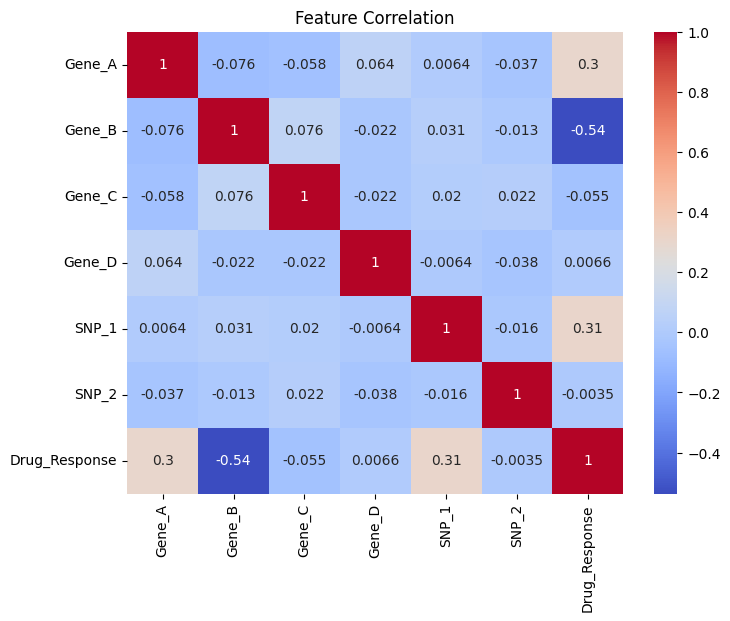

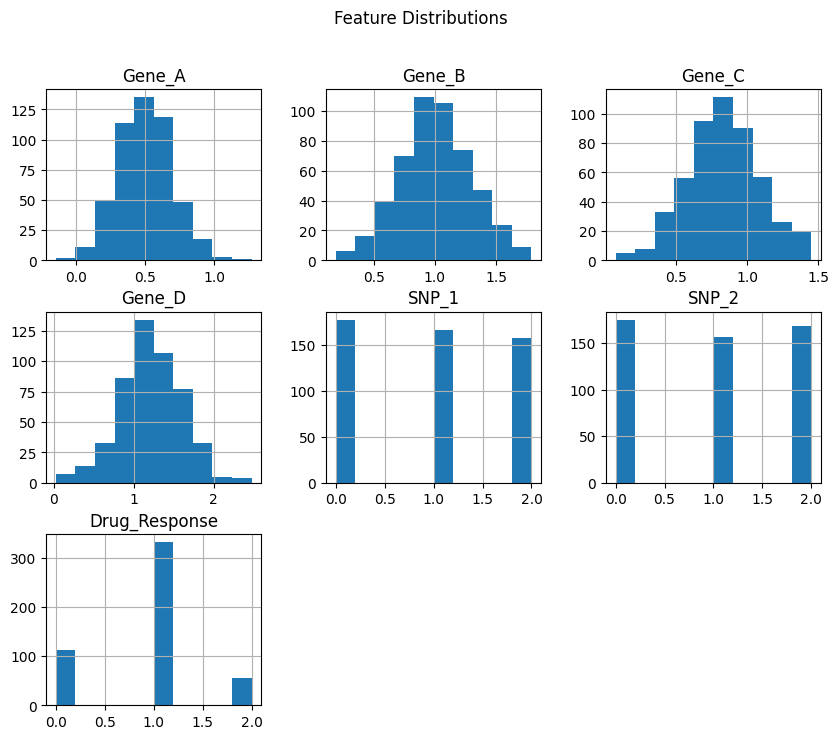


Random Forest Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       1.00      1.00      1.00        63
           2       1.00      0.79      0.88        14

    accuracy                           0.97       100
   macro avg       0.96      0.93      0.94       100
weighted avg       0.97      0.97      0.97       100


Gradient Boosting Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       1.00      1.00      1.00        63
           2       1.00      0.79      0.88        14

    accuracy                           0.97       100
   macro avg       0.96      0.93      0.94       100
weighted avg       0.97      0.97      0.97       100



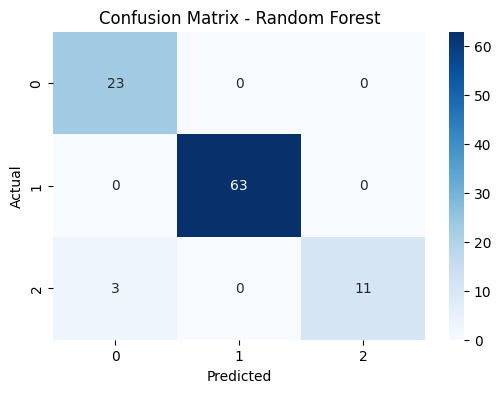

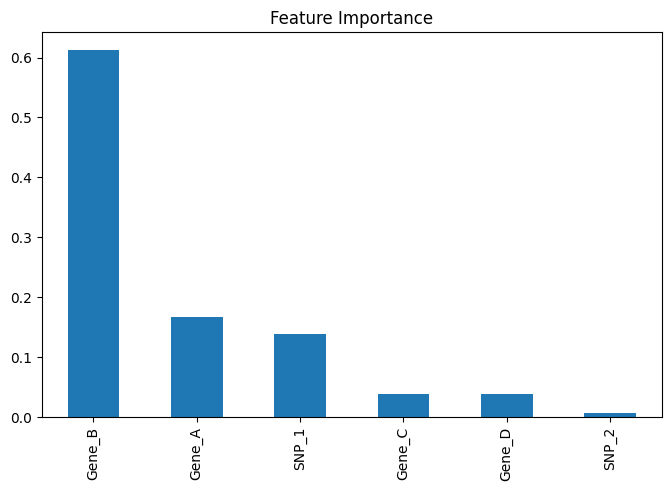


Top Important Features:
Gene_B    0.611993
Gene_A    0.166745
SNP_1     0.137829
Gene_C    0.038734
Gene_D    0.038451
SNP_2     0.006248
dtype: float64


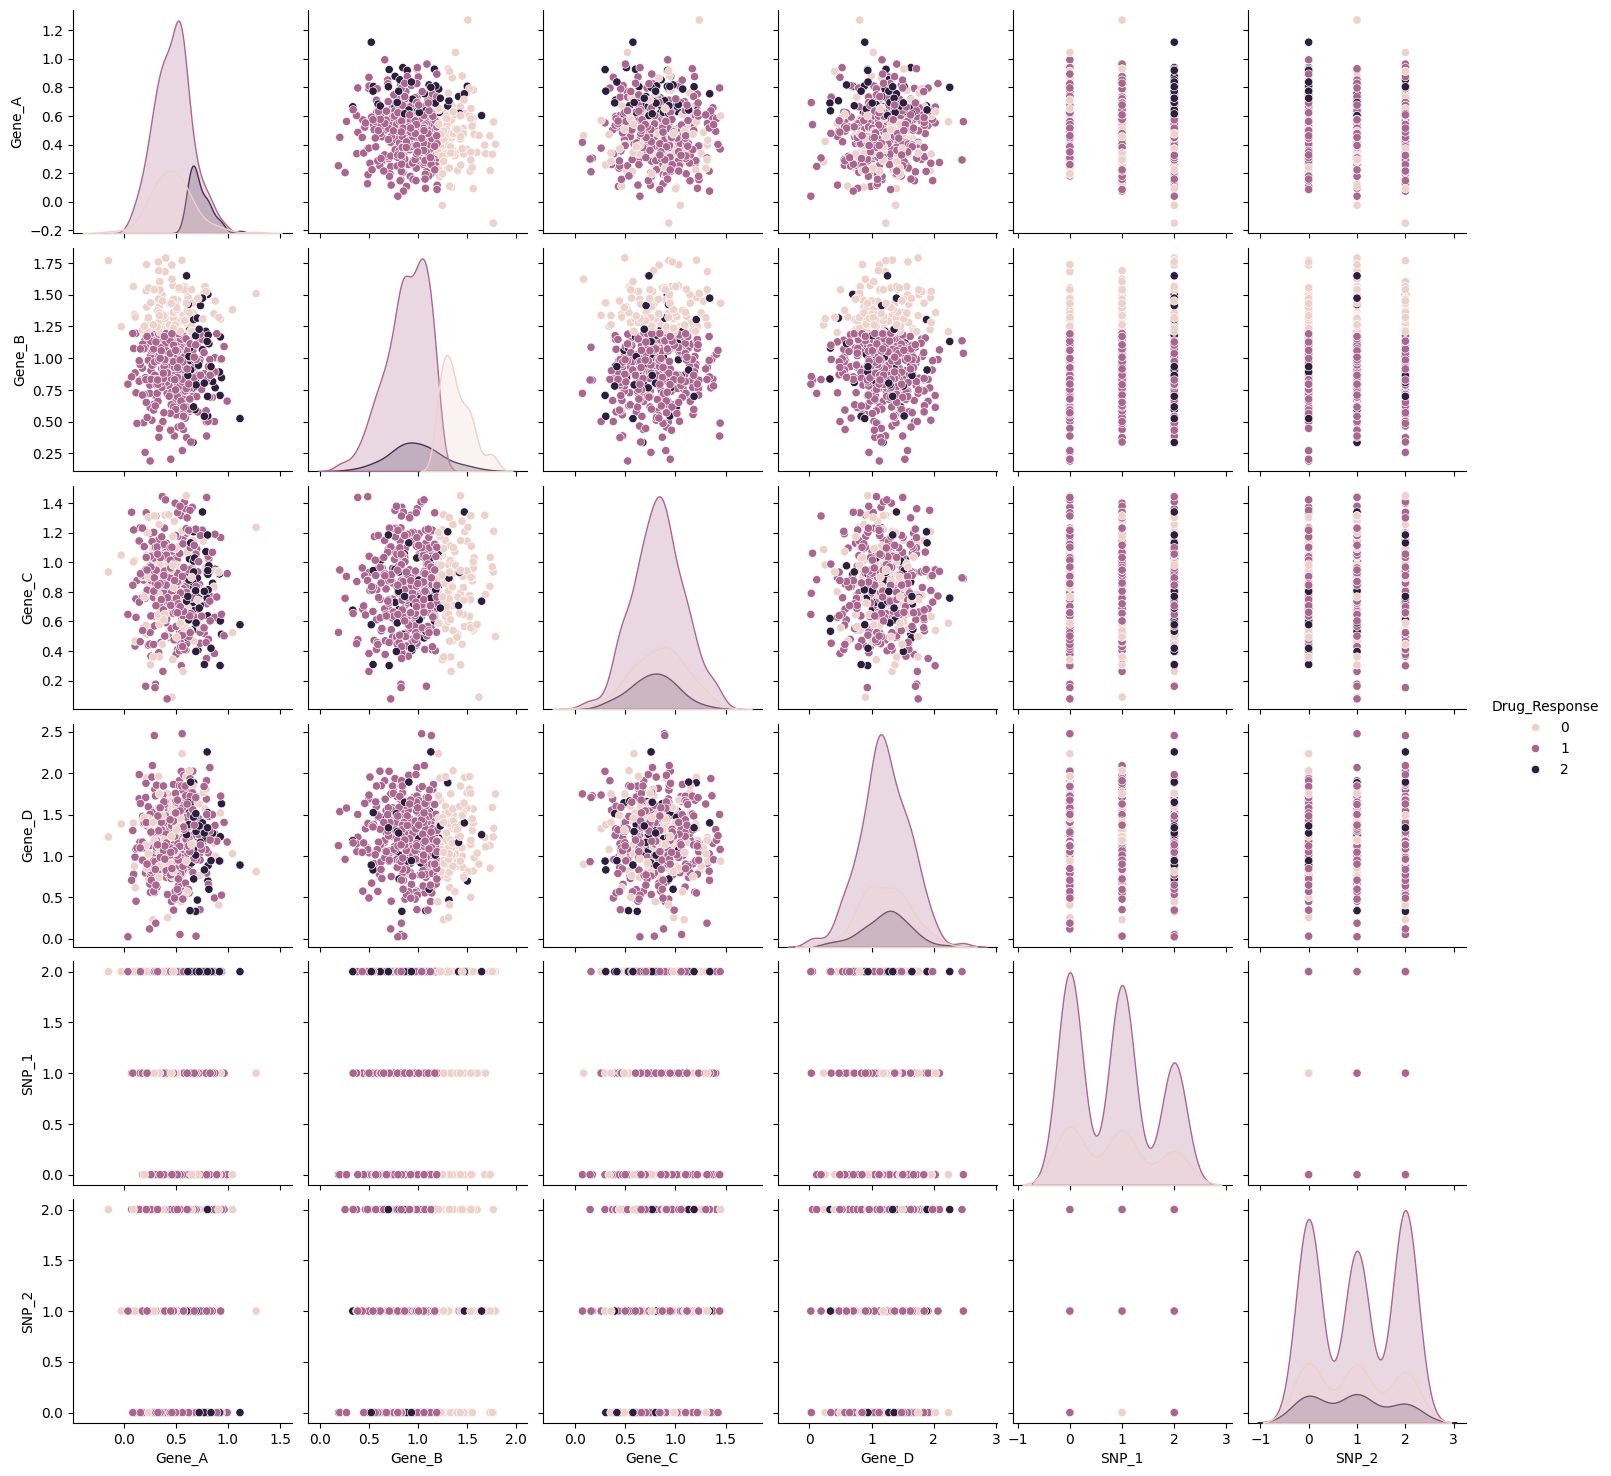


New Patient Prediction: [2]

Interpretation:
Higher Gene_A + SNP_1 GG leads to Toxic response
Higher Gene_B leads to Effective drug response
Model successfully captures genetic influence on drug response


In [1]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)

# =========================
# CREATE SYNTHETIC DATASET
# =========================
n_samples = 500

data = pd.DataFrame({
    'Gene_A': np.random.normal(0.5, 0.2, n_samples),
    'Gene_B': np.random.normal(1.0, 0.3, n_samples),
    'Gene_C': np.random.normal(0.8, 0.25, n_samples),
    'Gene_D': np.random.normal(1.2, 0.4, n_samples),
    'SNP_1': np.random.choice(['AA', 'AG', 'GG'], n_samples),
    'SNP_2': np.random.choice(['CC', 'CT', 'TT'], n_samples),
})

# Create target based on logic
conditions = []
for i in range(n_samples):
    if data.loc[i, 'Gene_A'] > 0.6 and data.loc[i, 'SNP_1'] == 'GG':
        conditions.append('Toxic')
    elif data.loc[i, 'Gene_B'] > 1.2:
        conditions.append('Effective')
    else:
        conditions.append('Ineffective')

data['Drug_Response'] = conditions

# =========================
# PREPROCESSING
# =========================
le = LabelEncoder()
data['SNP_1'] = le.fit_transform(data['SNP_1'])
data['SNP_2'] = le.fit_transform(data['SNP_2'])
data['Drug_Response'] = le.fit_transform(data['Drug_Response'])

# =========================
# EDA
# =========================

print("Dataset Head:")
print(data.head())

print("\nClass Distribution:")
print(data['Drug_Response'].value_counts())

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Distribution plots
data.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

# =========================
# SPLIT DATA
# =========================
X = data.drop('Drug_Response', axis=1)
y = data['Drug_Response']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# =========================
# MODEL 1: RANDOM FOREST
# =========================
rf = RandomForestClassifier(n_estimators=200, max_depth=6)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# =========================
# MODEL 2: GRADIENT BOOSTING
# =========================
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("\nGradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# FEATURE IMPORTANCE
# =========================
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

print("\nTop Important Features:")
print(importance)

# =========================
# ADVANCED ANALYSIS
# =========================

# Pairplot for relationships
sns.pairplot(data, hue='Drug_Response')
plt.show()

# =========================
# NEW PATIENT PREDICTION
# =========================
new_patient = pd.DataFrame({
    'Gene_A': [0.7],
    'Gene_B': [1.3],
    'Gene_C': [0.9],
    'Gene_D': [1.1],
    'SNP_1': [2],
    'SNP_2': [1]
})

new_patient_scaled = scaler.transform(new_patient)

prediction = rf.predict(new_patient_scaled)
print("\nNew Patient Prediction:", prediction)

# =========================
# INTERPRETATION
# =========================
print("\nInterpretation:")
print("Higher Gene_A + SNP_1 GG leads to Toxic response")
print("Higher Gene_B leads to Effective drug response")
print("Model successfully captures genetic influence on drug response")